# Model ID (hand) — kinematic fitting

Fits transmission models for all joints of the ADAPT Hand from recorded (θ, q) pairs.
Saves fitted coefficients to `hand_params.py`.

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pandas as pd
import os, sys, re

sys.path.insert(0, '..')
from plot_config import draw_radar, COLORS, FIG_W_SINGLE, FIG_W_DOUBLE, set_font_size
FIG_W = 10   # inches — change freely

FIG_H = 6    # inches — change freely

GRID = False
FONT_SIZE = 18  # pt — change to rescale all text uniformly
set_font_size(FONT_SIZE)
plt.rcParams['savefig.bbox'] = 'tight'
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

OUT_DIR = os.path.join('outputs', 'fitting')
os.makedirs(OUT_DIR, exist_ok=True)


def load_joint_data(filename):
    filepath = os.path.join('outputs/joint_data', filename)
    df = pd.read_csv(filepath)
    data = [(np.radians(row['q_deg']), np.radians(row['theta_deg'])) for _, row in df.iterrows()]
    print(f"Loaded {len(data)} points from {filepath}")
    return data


def fit_linear_model(data):
    def mse_cost(k):
        return np.mean([(k * theta - q)**2 for q, theta in data])
    result = minimize(mse_cost, [1.0], method='L-BFGS-B')
    k_sol = result.x[0]
    q_values = [q for q, _ in data]
    ss_tot = sum((q - np.mean(q_values))**2 for q in q_values)
    ss_res = sum((q - k_sol * theta)**2 for q, theta in data)
    r_squared = 1 - ss_res / ss_tot
    print(f"  k = {k_sol:.6f}  MSE = {result.fun:.6f}  R² = {r_squared:.6f}")
    return {'k': k_sol, 'mse': result.fun, 'r_squared': r_squared}


def fit_pulley_model(data, R=0.005):
    def mse_cost(r_pulley):
        return np.mean([((R / r_pulley) * q - theta)**2 for q, theta in data])
    result = minimize(mse_cost, [0.01], method='L-BFGS-B', bounds=[(1e-6, None)])
    r_sol = result.x[0]
    theta_values = [theta for _, theta in data]
    ss_tot = sum((t - np.mean(theta_values))**2 for t in theta_values)
    r_squared = 1 - (result.fun * len(data)) / ss_tot
    print(f"  r_pulley = {r_sol:.6f} m  R/r = {R/r_sol:.6f}  R² = {r_squared:.6f}")
    return {'r_pulley': r_sol, 'R': R, 'mse': result.fun, 'r_squared': r_squared}


def plot_linear_fit(data, k, joint_label, title=None, color_fit='C0', color_data='C1', save_name=None):
    """Plot measured data and fitted linear model q = k * theta.

    joint_label : str
        Short joint identifier shown next to theta on the y-axis, e.g. 'MCP', 'IP',
        'CMC$_1$'.
    title : str
        Title to print (not shown on plot).
    save_name : str, optional
        Filename to save the figure under OUT_DIR (e.g. 'index_MCP_linear_fit.pdf').
        If None, the figure is not saved.
    """
    if title is None:
        title = f'{joint_label} Joint: Linear Model Fit'
    print(f"\n{title}")
    print("=" * len(title))

    q_meas = [q for q, _ in data]
    theta_meas = [theta for _, theta in data]

    q_meas_deg = np.degrees(q_meas)
    theta_meas_deg = np.degrees(theta_meas)

    theta_fit = np.linspace(0, max(theta_meas), 100)
    q_fit = k * theta_fit
    theta_fit_deg = np.degrees(theta_fit)
    q_fit_deg = np.degrees(q_fit)

    # ---- size / aspect for THIS graph only (shared style applies to the rest) ----
    W_IN   = 8.5 * 0.52    # figure width (inches)
    ASPECT = 8 / 9         # height / width  ->  set to change proportions
    H_IN   = W_IN * ASPECT
    fig, ax = plt.subplots(figsize=(W_IN, H_IN))

    ax.plot(q_fit_deg, theta_fit_deg, '--',
            color=color_fit, label=r'$q = k \cdot \theta$', linewidth=2.5)
    ax.plot(q_meas_deg, theta_meas_deg, 'o',
            color=color_data, markersize=10, label='Measures')

    ax.set_xlabel(r'Joint angle ($^\circ$)')
    ax.set_ylabel(rf'{joint_label} $\theta$ ($^\circ$)')
    ax.legend()

    plt.tight_layout()
    if save_name:
        fig.savefig(os.path.join(OUT_DIR, save_name))
    plt.show()


def plot_pulley_fit(data, r_pulley, R, joint_label, title=None, color_fit='C0', color_data='C1', save_name=None):
    """Plot measured data and fitted pulley model theta = (R/r) * q.

    joint_label : str
        Short joint identifier shown next to theta on the y-axis, e.g. 'CMC$_1$'.
    title : str
        Title to print (not shown on plot).
    save_name : str, optional
        Filename to save the figure under OUT_DIR (e.g. 'thumb_CMC1_pulley_fit.pdf').
        If None, the figure is not saved.
    """
    if title is None:
        title = f'{joint_label} Joint: Pulley Model Fit'
    print(f"\n{title}")
    print("=" * len(title))

    q_meas_deg    = np.degrees([q for q, _ in data])
    theta_meas_deg = np.degrees([theta for _, theta in data])
    q_fit_deg = np.linspace(0, max(q_meas_deg), 100)
    theta_fit_deg = (R / r_pulley) * q_fit_deg

    # ---- size / aspect for THIS graph only (shared style applies to the rest) ----
    W_IN   = 8.5 * 0.52    # figure width (inches)
    ASPECT = 8 / 9         # height / width  ->  set to change proportions
    H_IN   = W_IN * ASPECT
    fig, ax = plt.subplots(figsize=(W_IN, H_IN))

    ax.plot(q_fit_deg, theta_fit_deg, '--',
            color=color_fit, label=r'$\theta = \frac{R}{r}\,q$', linewidth=2.5)
    ax.plot(q_meas_deg, theta_meas_deg, 'o',
            color=color_data, markersize=10, label='Measures')

    ax.set_xlabel(r'Joint angle ($^\circ$)')
    ax.set_ylabel(rf'{joint_label} $\theta$ ($^\circ$)')
    ax.legend()

    plt.tight_layout()
    if save_name:
        fig.savefig(os.path.join(OUT_DIR, save_name))
    plt.show()

---
## 1. Thumb Joints

### 1.1 Thumb CMC1 (flexion/extension) — Pulley model

Loaded 5 points from outputs/joint_data\thumb_CMC1_joint_data.csv
  r_pulley = 0.013457 m  R/r = 0.371559  R² = 0.976899

Thumb CMC1: Pulley Model Fit


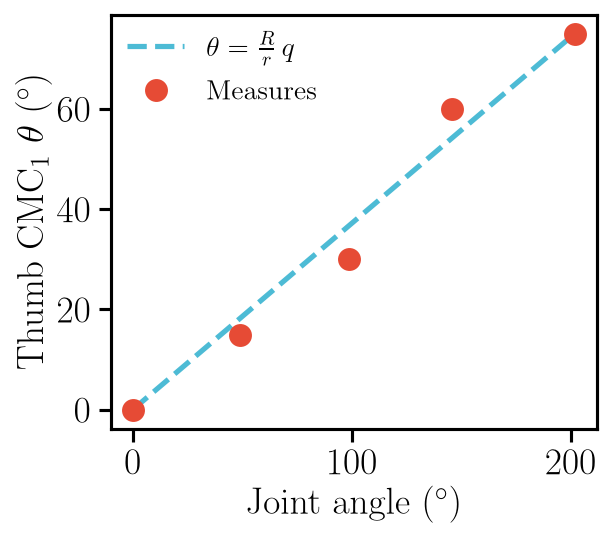

In [2]:
data_CMC1 = load_joint_data('thumb_CMC1_joint_data.csv')
res_CMC1 = fit_pulley_model(data_CMC1, R=0.005)
plot_pulley_fit(data_CMC1, res_CMC1['r_pulley'], res_CMC1['R'],
                 joint_label='Thumb CMC$_1$', title='Thumb CMC1: Pulley Model Fit',
                 save_name='thumb_CMC1_pulley_fit.pdf')

### 1.2 Thumb CMC2 (abduction/adduction) — Pulley model

Loaded 5 points from outputs/joint_data\thumb_CMC2_joint_data.csv
  r_pulley = 0.008834 m  R/r = 0.565967  R² = 0.975535

Thumb CMC2: Pulley Model Fit


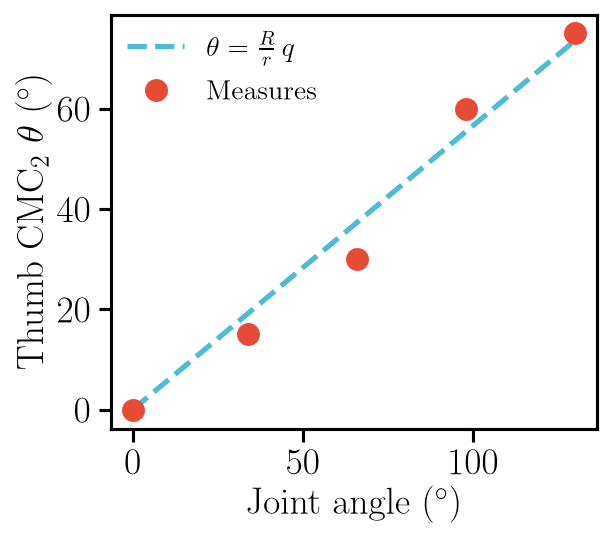

In [3]:
data_CMC2 = load_joint_data('thumb_CMC2_joint_data.csv')
res_CMC2 = fit_pulley_model(data_CMC2, R=0.005)
plot_pulley_fit(data_CMC2, res_CMC2['r_pulley'], res_CMC2['R'],
                 joint_label='Thumb CMC$_2$', title='Thumb CMC2: Pulley Model Fit',
                 save_name='thumb_CMC2_pulley_fit.pdf')

### 1.3 Thumb MCP — Linear model

Loaded 6 points from outputs/joint_data\thumb_MCP_joint_data.csv
  k = 1.209697  MSE = 0.000550  R² = 0.998067
  => c_MCP = k * r_motor = 0.006048 m

Thumb MCP: Linear Model Fit


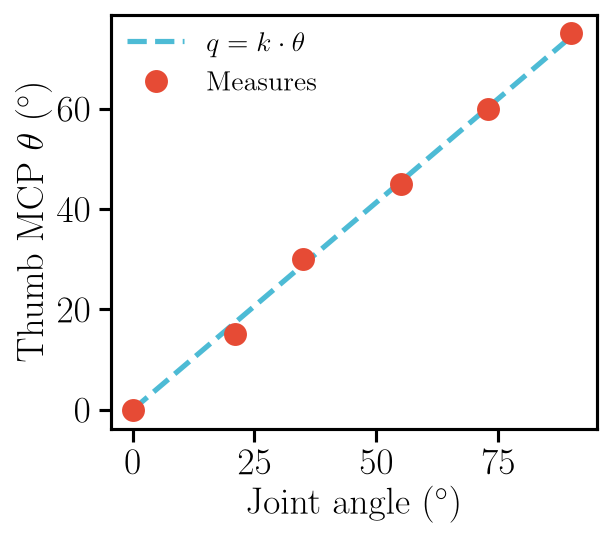

In [4]:
data_thumb_MCP = load_joint_data('thumb_MCP_joint_data.csv')
res_thumb_MCP = fit_linear_model(data_thumb_MCP)
print(f"  => c_MCP = k * r_motor = {res_thumb_MCP['k'] * 0.005:.6f} m")
plot_linear_fit(data_thumb_MCP, res_thumb_MCP['k'],
                 joint_label='Thumb MCP', title='Thumb MCP: Linear Model Fit',
                 save_name='thumb_MCP_linear_fit.pdf')

### 1.4 Thumb IP — Linear model

Loaded 6 points from outputs/joint_data\thumb_IP_joint_data.csv
  k = 1.153939  MSE = 0.001459  R² = 0.994422
  => c_IP = k * r_motor = 0.005770 m

Thumb IP: Linear Model Fit


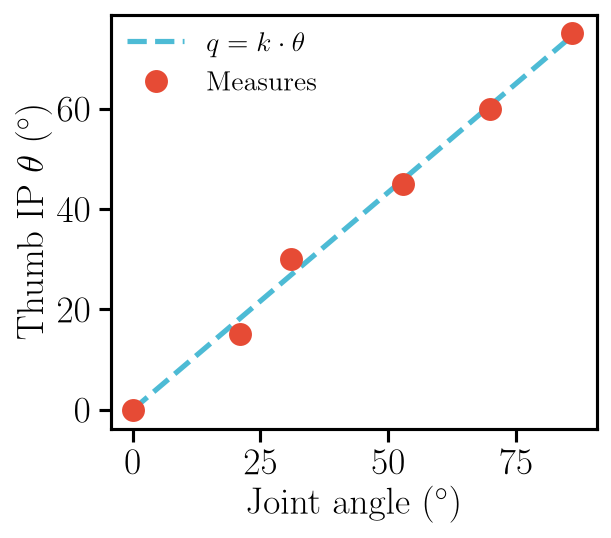

In [5]:
data_thumb_IP = load_joint_data('thumb_IP_joint_data.csv')
res_thumb_IP = fit_linear_model(data_thumb_IP)
print(f"  => c_IP = k * r_motor = {res_thumb_IP['k'] * 0.005:.6f} m")
plot_linear_fit(data_thumb_IP, res_thumb_IP['k'],
                 joint_label='Thumb IP', title='Thumb IP: Linear Model Fit',
                 save_name='thumb_IP_linear_fit.pdf')

---
## 2. Index Finger

=== Index MCP ===
Loaded 6 points from outputs/joint_data\index_MCP_joint_data.csv
  k = 1.643636  MSE = 0.000428  R² = 0.999206
  => r_pulley = r_motor / k = 0.003042 m

Index MCP: Linear Model Fit


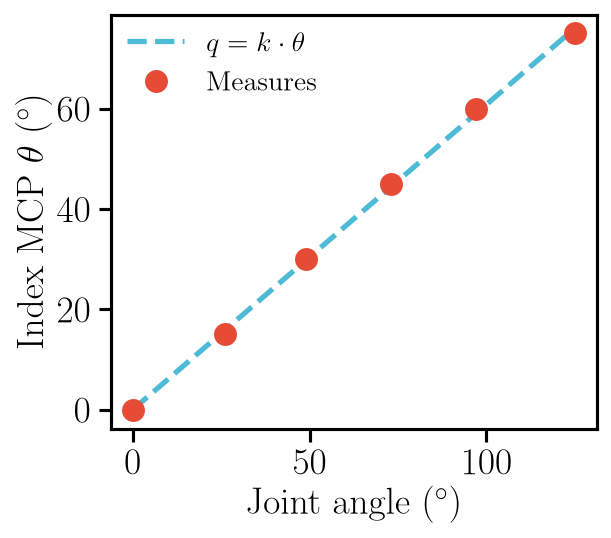


=== Index PIP ===
Loaded 6 points from outputs/joint_data\index_PIP_joint_data.csv
  k = 2.179394  MSE = 0.004962  R² = 0.994531
  => c_param = k * r_motor = 0.010897 m

Index PIP: Linear Model Fit


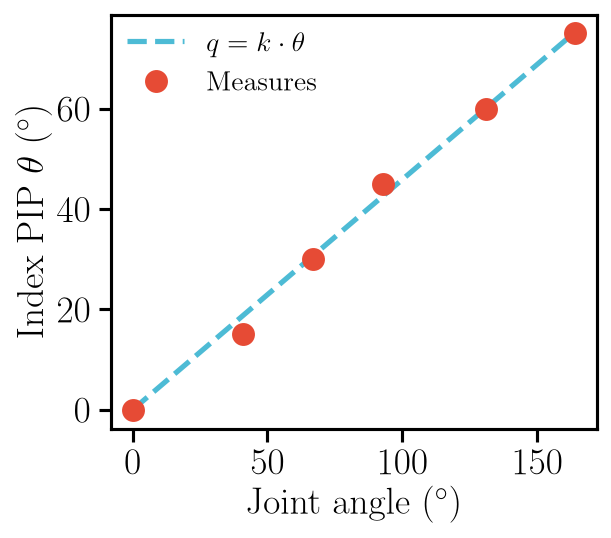

In [6]:
print("=== Index MCP ===")
data_index_MCP = load_joint_data('index_MCP_joint_data.csv')
res_index_MCP = fit_linear_model(data_index_MCP)
print(f"  => r_pulley = r_motor / k = {0.005 / res_index_MCP['k']:.6f} m")
plot_linear_fit(data_index_MCP, res_index_MCP['k'],
                 joint_label='Index MCP', title='Index MCP: Linear Model Fit',
                 save_name='index_MCP_linear_fit.pdf')

print("\n=== Index PIP ===")
data_index_PIP = load_joint_data('index_PIP_joint_data.csv')
res_index_PIP = fit_linear_model(data_index_PIP)
print(f"  => c_param = k * r_motor = {res_index_PIP['k'] * 0.005:.6f} m")
plot_linear_fit(data_index_PIP, res_index_PIP['k'],
                 joint_label='Index PIP', title='Index PIP: Linear Model Fit',
                 save_name='index_PIP_linear_fit.pdf')

---
## 3. Middle Finger

=== Middle MCP ===
Loaded 6 points from outputs/joint_data\middle_MCP_joint_data.csv
  k = 1.643636  MSE = 0.000428  R² = 0.999206
  => r_pulley = r_motor / k = 0.003042 m

Middle MCP: Linear Model Fit


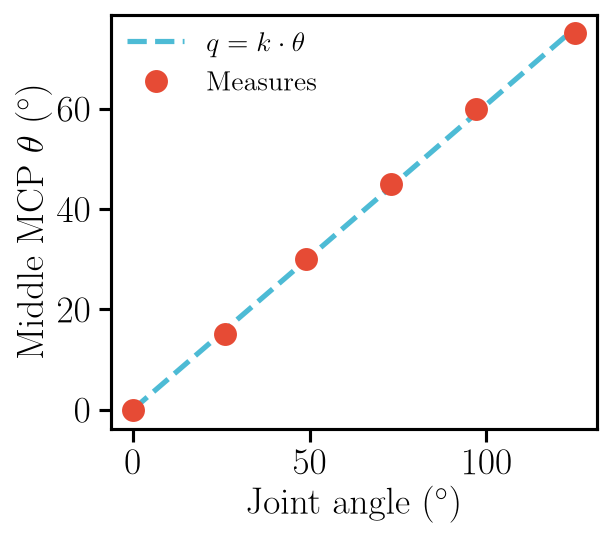


=== Middle PIP ===
Loaded 6 points from outputs/joint_data\middle_PIP_joint_data.csv
  k = 2.253333  MSE = 0.009636  R² = 0.989822
  => c_param = k * r_motor = 0.011267 m

Middle PIP: Linear Model Fit


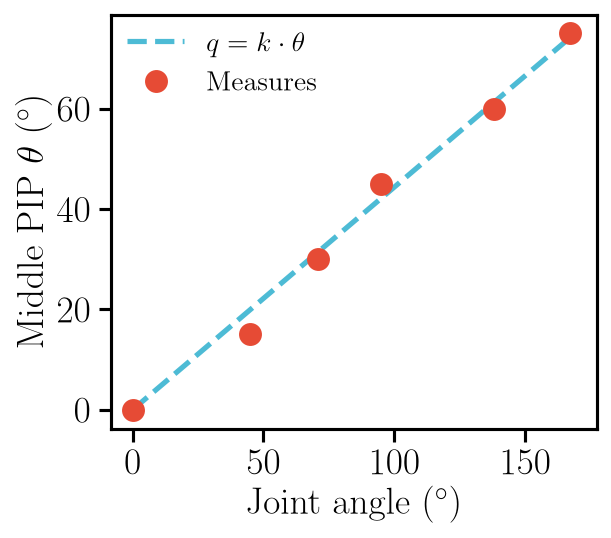

In [7]:
print("=== Middle MCP ===")
data_middle_MCP = load_joint_data('middle_MCP_joint_data.csv')
res_middle_MCP = fit_linear_model(data_middle_MCP)
print(f"  => r_pulley = r_motor / k = {0.005 / res_middle_MCP['k']:.6f} m")
plot_linear_fit(data_middle_MCP, res_middle_MCP['k'],
                 joint_label='Middle MCP', title='Middle MCP: Linear Model Fit',
                 save_name='middle_MCP_linear_fit.pdf')

print("\n=== Middle PIP ===")
data_middle_PIP = load_joint_data('middle_PIP_joint_data.csv')
res_middle_PIP = fit_linear_model(data_middle_PIP)
print(f"  => c_param = k * r_motor = {res_middle_PIP['k'] * 0.005:.6f} m")
plot_linear_fit(data_middle_PIP, res_middle_PIP['k'],
                 joint_label='Middle PIP', title='Middle PIP: Linear Model Fit',
                 save_name='middle_PIP_linear_fit.pdf')

---
## 4. Ring Finger

=== Ring MCP ===
Loaded 6 points from outputs/joint_data\ring_MCP_joint_data.csv
  k = 1.643636  MSE = 0.000428  R² = 0.999206
  => r_pulley = r_motor / k = 0.003042 m

Ring MCP: Linear Model Fit


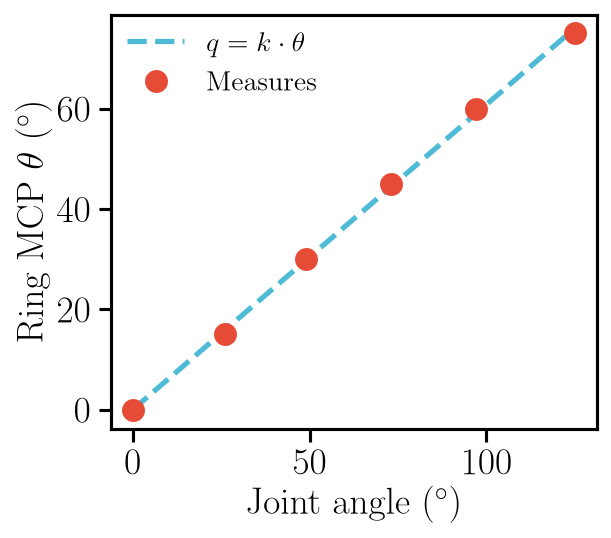


=== Ring PIP ===
Loaded 6 points from outputs/joint_data\ring_PIP_joint_data.csv
  k = 2.179394  MSE = 0.004962  R² = 0.994531
  => c_param = k * r_motor = 0.010897 m

Ring PIP: Linear Model Fit


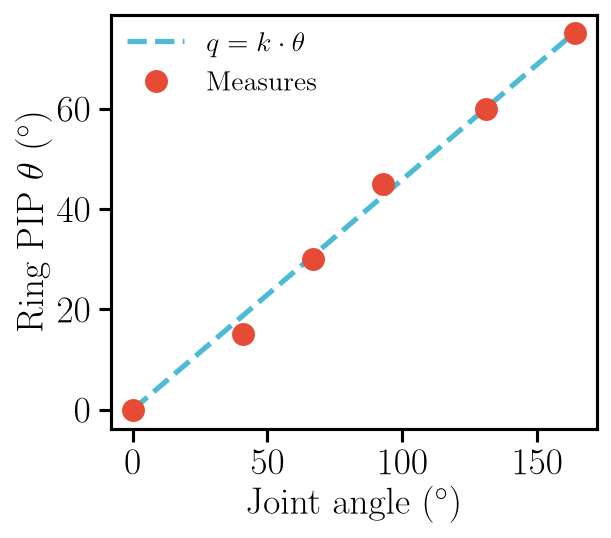

In [8]:
print("=== Ring MCP ===")
data_ring_MCP = load_joint_data('ring_MCP_joint_data.csv')
res_ring_MCP = fit_linear_model(data_ring_MCP)
print(f"  => r_pulley = r_motor / k = {0.005 / res_ring_MCP['k']:.6f} m")
plot_linear_fit(data_ring_MCP, res_ring_MCP['k'],
                 joint_label='Ring MCP', title='Ring MCP: Linear Model Fit',
                 save_name='ring_MCP_linear_fit.pdf')

print("\n=== Ring PIP ===")
data_ring_PIP = load_joint_data('ring_PIP_joint_data.csv')
res_ring_PIP = fit_linear_model(data_ring_PIP)
print(f"  => c_param = k * r_motor = {res_ring_PIP['k'] * 0.005:.6f} m")
plot_linear_fit(data_ring_PIP, res_ring_PIP['k'],
                 joint_label='Ring PIP', title='Ring PIP: Linear Model Fit',
                 save_name='ring_PIP_linear_fit.pdf')

---
## 5. Pinky Finger

=== Pinky MCP ===
Loaded 6 points from outputs/joint_data\pinky_MCP_joint_data.csv
  k = 1.643636  MSE = 0.000428  R² = 0.999206
  => r_pulley = r_motor / k = 0.003042 m

Pinky MCP: Linear Model Fit


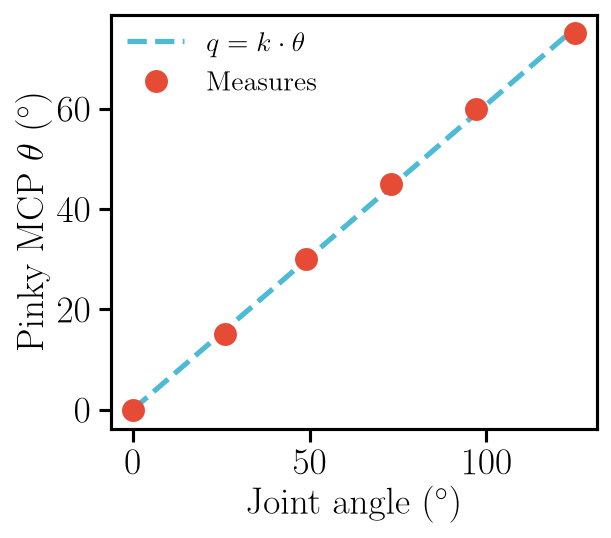


=== Pinky PIP ===
Loaded 6 points from outputs/joint_data\pinky_PIP_joint_data.csv
  k = 1.933333  MSE = 0.008479  R² = 0.989676
  => c_param = k * r_motor = 0.009667 m

Pinky PIP: Linear Model Fit


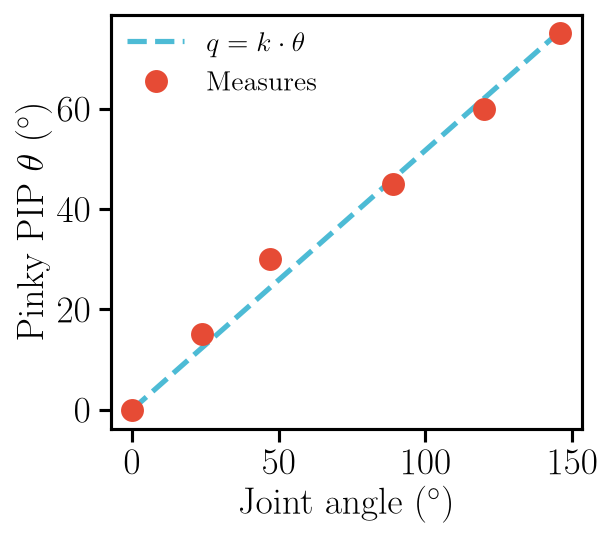

In [9]:
print("=== Pinky MCP ===")
data_pinky_MCP = load_joint_data('pinky_MCP_joint_data.csv')
res_pinky_MCP = fit_linear_model(data_pinky_MCP)
print(f"  => r_pulley = r_motor / k = {0.005 / res_pinky_MCP['k']:.6f} m")
plot_linear_fit(data_pinky_MCP, res_pinky_MCP['k'],
                 joint_label='Pinky MCP', title='Pinky MCP: Linear Model Fit',
                 save_name='pinky_MCP_linear_fit.pdf')

print("\n=== Pinky PIP ===")
data_pinky_PIP = load_joint_data('pinky_PIP_joint_data.csv')
res_pinky_PIP = fit_linear_model(data_pinky_PIP)
print(f"  => c_param = k * r_motor = {res_pinky_PIP['k'] * 0.005:.6f} m")
plot_linear_fit(data_pinky_PIP, res_pinky_PIP['k'],
                 joint_label='Pinky PIP', title='Pinky PIP: Linear Model Fit',
                 save_name='pinky_PIP_linear_fit.pdf')

---
## 6. Summary & Save to hand_params.py

In [10]:
# Collect all fitted parameters
r_motor = 0.005

fitted = {
    'thumb': {
        'CMC1_pulley': res_CMC1['r_pulley'],
        'CMC2_pulley': res_CMC2['r_pulley'],
        'MCP_c':       res_thumb_MCP['k'] * r_motor,
        'IP_c':        res_thumb_IP['k'] * r_motor,
    },
    'index': {
        'r_pulley': r_motor / res_index_MCP['k'],
        'c_param':  res_index_PIP['k'] * r_motor,
    },
    'middle': {
        'r_pulley': r_motor / res_middle_MCP['k'],
        'c_param':  res_middle_PIP['k'] * r_motor,
    },
    'ring': {
        'r_pulley': r_motor / res_ring_MCP['k'],
        'c_param':  res_ring_PIP['k'] * r_motor,
    },
    'pinky': {
        'r_pulley': r_motor / res_pinky_MCP['k'],
        'c_param':  res_pinky_PIP['k'] * r_motor,
    },
}

print("=" * 60)
print("FITTED TRANSMISSION PARAMETERS")
print("=" * 60)
print(f"\nThumb:")
print(f"  CMC1_pulley = {fitted['thumb']['CMC1_pulley']:.5f} m")
print(f"  CMC2_pulley = {fitted['thumb']['CMC2_pulley']:.5f} m")
print(f"  MCP_c       = {fitted['thumb']['MCP_c']:.5f} m")
print(f"  IP_c        = {fitted['thumb']['IP_c']:.5f} m")
for finger in ['index', 'middle', 'ring', 'pinky']:
    print(f"\n{finger.capitalize()}:")
    print(f"  r_pulley = {fitted[finger]['r_pulley']:.5f} m")
    print(f"  c_param  = {fitted[finger]['c_param']:.5f} m")

FITTED TRANSMISSION PARAMETERS

Thumb:
  CMC1_pulley = 0.01346 m
  CMC2_pulley = 0.00883 m
  MCP_c       = 0.00605 m
  IP_c        = 0.00577 m

Index:
  r_pulley = 0.00304 m
  c_param  = 0.01090 m

Middle:
  r_pulley = 0.00304 m
  c_param  = 0.01127 m

Ring:
  r_pulley = 0.00304 m
  c_param  = 0.01090 m

Pinky:
  r_pulley = 0.00304 m
  c_param  = 0.00967 m


In [11]:
# Save fitted parameters to hand_params.py
params_path = 'hand_params.py'

with open(params_path, 'r') as f:
    content = f.read()

# Update THUMB_TRANSMISSION values
content = re.sub(
    r'("CMC1_pulley":\s*)([\d.]+)',
    lambda m: f'{m.group(1)}{fitted["thumb"]["CMC1_pulley"]:.5f}',
    content
)
content = re.sub(
    r'("CMC2_pulley":\s*)([\d.]+)',
    lambda m: f'{m.group(1)}{fitted["thumb"]["CMC2_pulley"]:.5f}',
    content
)
content = re.sub(
    r'("MCP_c":\s*)([\d.]+)',
    lambda m: f'{m.group(1)}{fitted["thumb"]["MCP_c"]:.5f}',
    content
)
content = re.sub(
    r'("IP_c":\s*)([\d.]+)',
    lambda m: f'{m.group(1)}{fitted["thumb"]["IP_c"]:.5f}',
    content
)

# Update FINGER_TRANSMISSIONS values per finger
for finger in ['index', 'middle', 'ring', 'pinky']:
    # Find the finger block and update r_pulley and c_param within it
    pattern = rf'("{finger}":\s*\{{[^}}]*?"r_pulley":\s*)([\d.]+)'
    content = re.sub(
        pattern,
        lambda m, f=finger: f'{m.group(1)}{fitted[f]["r_pulley"]:.5f}',
        content
    )
    pattern = rf'("{finger}":\s*\{{[^}}]*?"c_param":\s*)([\d.]+)'
    content = re.sub(
        pattern,
        lambda m, f=finger: f'{m.group(1)}{fitted[f]["c_param"]:.5f}',
        content
    )

with open(params_path, 'w') as f:
    f.write(content)

print(f"Parameters saved to {params_path}")

Parameters saved to hand_params.py
